In [ ]:
import pyguidos
import shutil
import rasterio
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap

In [15]:
cwd = os.getcwd()

src_map = os.path.join(cwd, 'examples/data/binarymap.tif')
bin_map = os.path.join(cwd, 'examples/input/binarymap.tif')
shutil.copy(src_map, bin_map)


'examples/input/binarymap.tif'

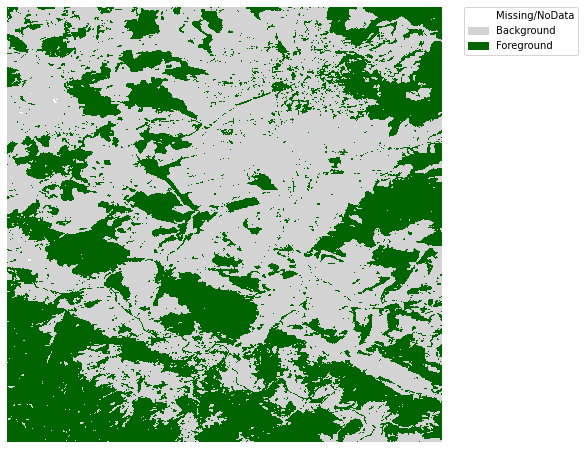

In [60]:
with rasterio.open(bin_map) as src:
    data = src.read(1)

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['white', 'lightgrey', 'darkgreen'] 
cmap = ListedColormap(colors)
im = ax.imshow(data, cmap=cmap, vmin=-0.5, vmax=2.5)
legend_labels = {
    0: 'Missing/NoData', 
    1: 'Background',     
    2: 'Foreground'     
}

patches = []
for val in sorted(legend_labels.keys()): 
    label = legend_labels[val]
    color = colors[val] 
    patch = mpatches.Patch(color=color, label=label)
    patches.append(patch)
legend = ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.axis('off')
plt.show()

In [28]:
cwd = os.getcwd()

in_dir = os.path.join(cwd, 'examples/input')
out_dir = os.path.join(cwd, 'examples/output')
pyguidos.gwb_dist(in_dir, out_dir, conn_8=True, eucl_hysom=True)

GWB_DIST using:
dir_input= /home/caudugi/git_rep/pyguidosx/examples/input
dir_output= /home/caudugi/git_rep/pyguidosx/examples/output
Done with: binarymap.tif
DIST finished sucessfully



In [37]:
map_name = bin_map.split('/')[-1][:-4]
res_dir = os.path.join(cwd, 'examples/output', map_name + '_dist')

dist_map = os.path.join(res_dir, map_name + '_dist.tif')
dist_map_vp = os.path.join(res_dir , map_name + '_dist_viewport.tif')
dist_map_hist = os.path.join(res_dir, map_name + '_dist_hist.png')
dist_map_txt = os.path.join(res_dir, map_name + '_dist.txt')

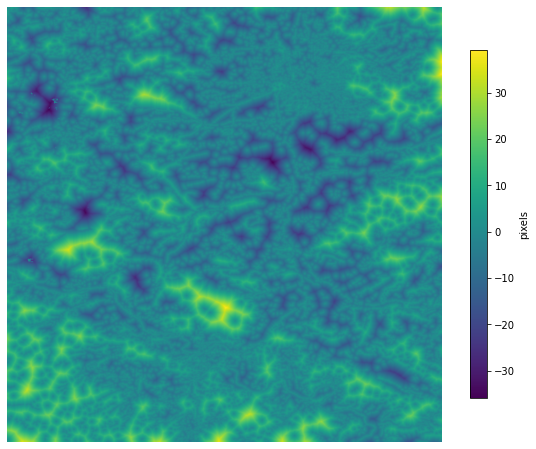

In [55]:
with rasterio.open(dist_map) as src:
    data = src.read(1)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(data, cmap='viridis')
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.8, pad=0.05)
cbar.set_label('pixels')
plt.axis('off')
plt.show()

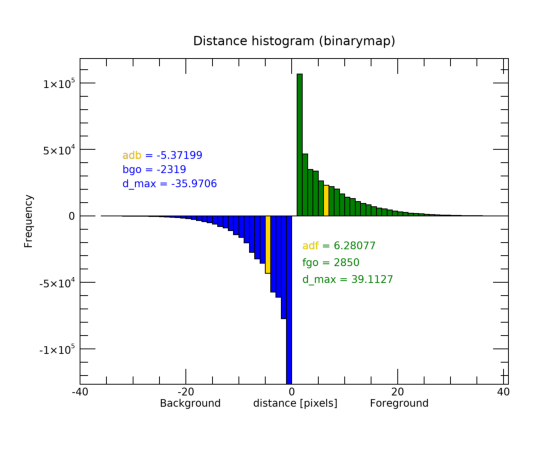

In [52]:
fig, ax = plt.subplots(figsize=(10, 8))
img = mpimg.imread(dist_map_hist)
ax.imshow(img)
ax.axis('off')
plt.show()

In [53]:
with open(dist_map_txt, 'r', encoding='utf-8') as f:
    txt = f.read()
    print(txt)

Euclidean distance result using file: binarymap
Background: average distance, number of objects, maximum distance: 
-5.37199  -2319  -35.9706
Foreground: average distance, number of objects, maximum distance: 
 6.28077   2850   39.1127
Distance histogram (rounded to nearest integer, negative values for background)
       bin ID     frequency
         -36                    -3
         -35                   -17
         -34                   -62
         -33                  -109
         -32                  -150
         -31                  -196
         -30                  -235
         -29                  -277
         -28                  -339
         -27                  -431
         -26                  -518
         -25                  -644
         -24                  -790
         -23                  -974
         -22                 -1224
         -21                 -1616
         -20                 -2026
         -19                 -2654
         -18              